# Higher-order (p=2) FEM in one dimension: hierarchical basis
Tested on a diffusion problem

We solve
$$
u'' + 50e^x = 0, \qquad x \in [-1,1],
$$
with boundary conditions
$$
u(-1)=100, \qquad u(1)=100.
$$

We use:
- quadratic finite elements,
- Gaussian quadrature for the forcing term,
- direct solution of the assembled linear system.

In [1]:
using LinearAlgebra
using Plots

### Problem setup and quadrature rule

In [14]:
# Number of Gauss points
Nq = 3

# Gauss quadrature points and weights on [-1,1]
xiq, aq = if Nq == 3
    ([-sqrt(3/5), 0.0, sqrt(3/5)],
     [5/9, 8/9, 5/9])
elseif Nq == 2
    ([-1/sqrt(3), 1/sqrt(3)],
     [1.0, 1.0])
else
    ([0.0], [2.0])
end

# Number of elements
nElem = 10

# Element boundary nodes
xn = collect(range(-1.0, 1.0, length=nElem+1))

# Total number of global degrees of freedom for quadratic elements
nDOF = 2*nElem + 1

21

### Local element matrix and hierarchical basis functions

In [15]:
# Local stiffness matrix for the hierarchical quadratic basis
Ke = [
    -1/2    0    1/2
      0   -2/3   0
     1/2    0   -1/2
]

# Quadratic hierarchical basis functions on the reference element xi in [-1,1]
function phi_quad(xi)
    return [
        0.5 * (1 - xi),
        0.5 * (xi^2 - 1),
        0.5 * (1 + xi)
    ]
end

# Exact solution used in the MATLAB script
u_exact(x) = -50*exp(x) + 50*x*sinh(1) + 100 + 50*cosh(1);

### Assemble the global stiffness matrix and load vector

In [16]:
# Initialize global stiffness matrix and RHS
K = zeros(nDOF, nDOF)
F = zeros(nDOF)

for elem in 1:nElem
    # Global node numbers for this element
    n = 2*(elem-1) .+ [1, 2, 3]

    xL = xn[elem]
    xR = xn[elem+1]

    dx    = xR - xL
    dxidx = 2 / dx
    dxdxi = dx / 2

    # Stiffness matrix contribution
    K[n, n] .+= dxidx * Ke

    # Quadrature for forcing term
    for q in 1:Nq
        xi = xiq[q]
        w  = aq[q]

        phi = phi_quad(xi)

        # Map xi to physical coordinate x
        x = 0.5*(1 - xi)*xL + 0.5*(1 + xi)*xR

        # Source term from the original script
        f = -50 * exp(x)

        # Element load contribution
        g = phi .* f .* dxdxi

        F[n] .+= w .* g
    end
end

### Apply Dirichlet boundary conditions

In [17]:
# Left boundary: u(-1) = 100
left_node = 1
K[left_node, :] .= 0.0
K[left_node, left_node] = 1.0
F[left_node] = 100.0

# Right boundary: u(1) = 100
right_node = nDOF
K[right_node, :] .= 0.0
K[right_node, right_node] = 1.0
F[right_node] = 100.0;

### Solve for the nodal values

In [18]:
T = K \ F
T

21-element Vector{Float64}:
 100.0
  -0.20348821636291534
 107.67953579036568
  -0.24854106871875847
 114.45741412903725
  -0.30356874684916757
 120.13400556929396
  -0.37077970469279986
 124.46548215430107
  -0.4528713539815989
 127.15403174506412
  -0.5531383208448557
 127.83590577360165
  -0.6756046707239917
 126.06682073570437
  -0.8251854082481763
 121.30412753392591
  -1.0078837336278494
 112.88503306393218
  -1.231031972157824
 100.0

## Sample the FEM solution inside each element for plotting

Because the approximation is quadratic on each element, we evaluate the solution at several points per element to see the curved profile.

In [19]:
Nplot = 20

xp = Float64[]
Tp = Float64[]
up = Float64[]

for elem in 1:nElem
    n = 2*(elem-1) .+ [1, 2, 3]

    xL = xn[elem]
    xR = xn[elem+1]

    Te = T[n]

    for nn in 1:Nplot
        xi = -1 + 2*(nn-1)/(Nplot-1)

        phi = phi_quad(xi)

        x = 0.5*(1 - xi)*xL + 0.5*(1 + xi)*xR
        uh = dot(Te, phi)

        push!(xp, x)
        push!(Tp, uh)
        push!(up, u_exact(x))
    end
end

## Plot FEM solution and exact solution

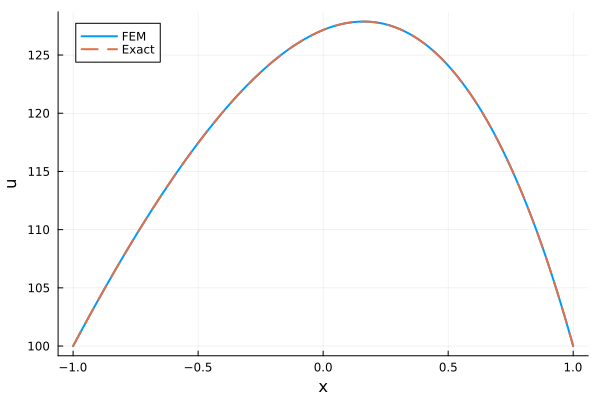

In [20]:
plot(xp, Tp,
    lw = 2,
    label = "FEM",
    xlabel = "x",
    ylabel = "u",
    grid = true)

plot!(xp, up,
    lw = 2,
    ls = :dash,
    label = "Exact")

### Plot the error

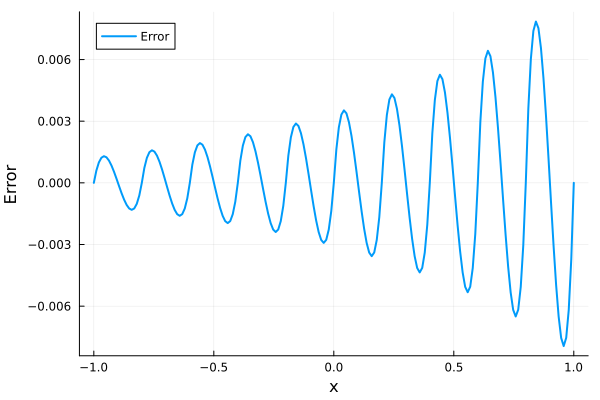

In [21]:
err = Tp .- up

plot(xp, err,
    lw = 2,
    label = "Error",
    xlabel = "x",
    ylabel = "Error",
    grid = true)

In [22]:
println("Maximum error = ", maximum(abs.(err)))

Maximum error = 0.007940368738942993


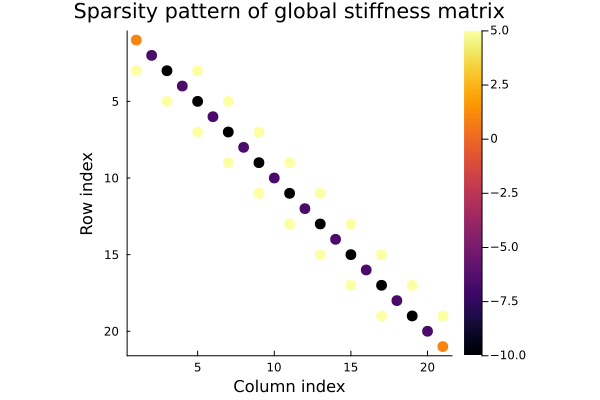

In [23]:
using SparseArrays
using Plots

spy(sparse(K),
    c = :black,
    markerstrokecolor = :black,
    markersize = 6,
    xlabel = "Column index",
    ylabel = "Row index",
    title = "Sparsity pattern of global stiffness matrix")

In [24]:
0.05792373915117821 / 0.007940368738928782

7.294842475916625